# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [1]:
# ===== IMPORTS =====

import numpy as np
import random
import matplotlib.pyplot as plt

/home/alice/.local/lib/python3.11/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
 
def jacobi(A, b, e: float, max_iter=1000, verbose=True) -> np.ndarray: 
    """
    resolve o sistema linear Ax = b pelo método de Jacobi.

    parâmetros:
    -----------
        A : matriz dos coeficientes (n x n), deve ser diagonalmente dominante
        b : vetor do lado direito (n x 1)
        e : tolerância para critério de parada (||x_new - x_old|| < e)
        max_iter : número máximo de iterações (padrão: 1000)
        verbose : se True, imprime progresso e resíduo final (padrão: True)
 
    retorna:
    -------
        erros : lista com a norma ||x_new - x_old|| a cada iteração
    """
    
    A = np.array(A)
    b = np.array(b)
    n = len(A)
 
    erros = []
    x_old = np.zeros(n)
    x_new = np.zeros(n)
 
    for i in range(max_iter): 
        x_old = x_new.copy()
 
        for j in range(n):
            soma = sum(A[j][k] * x_old[k] for k in range(n) if k != j)
            x_new[j] = (b[j] - soma)*(1/A[j][j])
 
        erro = np.linalg.norm(x_new - x_old)
        erros.append(erro)
 
        if np.isnan(erro) or np.isinf(erro):
            if verbose: print("Divergiu (overflow)")
            break
        
        # verifica se o erro cresceu nas últimas 'a' iterações consecutivas
        a = 5
        if i >= a and all(erros[i-j] > erros[i-j-1] for j in range(a)):
            if verbose: print("Divergiu")
            break
        
        if erro < e:
            if verbose: print(f"Convergiu em {i+1} iterações")
            break
 
    residuo = np.linalg.norm(A @ x_new - b)
    if verbose: print(f"Resíduo: {residuo:.2e}")
 
    return erros
 

 
 
def gauss_seidel(A, b, e: float, max_iter=1000, verbose=True):
    """
    resolve o sistema linear Ax = b por Gauss-Seidel.
 
    parâmetros:
    ----------
        A : matriz dos coeficientes (n x n), deve ser diagonalmente dominante
        b : vetor do lado direito (n,)
        e : tolerância para critério de parada (||x_new - x_old|| < e)
        max_iter : número máximo de iterações (padrão: 1000)
        verbose : se True, imprime progresso e resíduo final (padrão: True)
 
    retorna:
    -------
        erros : lista com a norma ||x_new - x_old|| a cada iteração
    """
 
    A = np.array(A)
    b = np.array(b)
    n = len(A)
 
    erros = []
    x_old = np.zeros(n)
    x_new = np.zeros(n)
 
    for i in range(max_iter):
        x_old = x_new.copy()
        
        for j in range(n):
            # usa x_new (já atualizado) em vez de x_old (diferença principal em relação a Jacobi)
            soma = sum(A[j][k] * x_new[k] for k in range(n) if k != j)
            x_new[j] = (b[j] - soma)*(1/A[j][j])
 
        erro = np.linalg.norm(x_new - x_old)
        erros.append(erro)
 
        if np.isnan(erro) or np.isinf(erro):
            if verbose: print("Divergiu (overflow)")
            divergiu = True
            break
        
        # verifica se o erro cresceu nas últimas 'a' iterações consecutivas
        a = 5
        if i >= a and all(erros[i-j] > erros[i-j-1] for j in range(a)):
            if verbose: print("Divergiu")
            break
        
        if erro < e:
            if verbose: print(f"Convergiu em {i+1} iterações")
            break
 
    residuo = np.linalg.norm(A @ x_new - b)
    if verbose: print(f"Resíduo: {residuo:.2e}")
 
    return erros




Qual deveria ser a complexidade computacional do código que você escreveu?

<u>Comentários:</u>   Quebrando o cálculo da complexidade em funções:

i) `jacobi`: 
Note que a parte mais crítica seria o loop que calcula x_new, onde temos um loop externo: n e um loop interno(sum): n. Assim, o custo é de O(n²). As outras partes da função, como `np.linalg.norm` e `x_new.copy()` possuem complexidade O(n). 

Como o algoritmo é iterativo, a complexidade computacional da função `jacobi` é O(k*n²), onde k é a quantidade de iterações até convergir.


ii) `gauss_seidel`:
A função `gauss_seidel` é muito semelhante à jacobi, com a principal diferença estando na forma como o vetor x é atualizado (utilizando os valores já atualizados dentro da mesma iteração). A parte mais crítica continua sendo o cálculo de x_new, onde há um loop externo de tamanho n e, dentro dele, um somatório que também percorre até n elementos. Logo, essa etapa possui custo O(n²). As demais operações, como o cálculo da norma e a cópia de vetores, possuem custo linear O(n).

Como o algoritmo é iterativo, a complexidade da função gauss_seidel é O(k*n²), onde k é o número de iterações.

Dessa forma, a complexidade computacional do meu código é O(k*n²), onde k é o número de iterações até convergência.


_OBS:_ Note que o custo de calcular o resídulo `np.linalg.norm(A @ x - b)` custa O(n²), já que `np.linalg.norm` custa O(n) mas o produto `A @ x` pra uma matriz densa nxn custa O(n²), o que não altera o custo total de nenhuma das funções.

_OBS_: O uso do parâmetro bool verbose na entrada das funções é para que seja arbitrário a plotagem dos gráficos (não é muito útil plotar os gráficos na letra (f), por exemplo)

## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

========== TAMANHO = 2 x 2 ==========
Jacobi:
Convergiu em 353 iterações
Resíduo: 3.06e-08
--------
Gauss-Seidel:
Convergiu em 164 iterações
Resíduo: 3.07e-08
--------


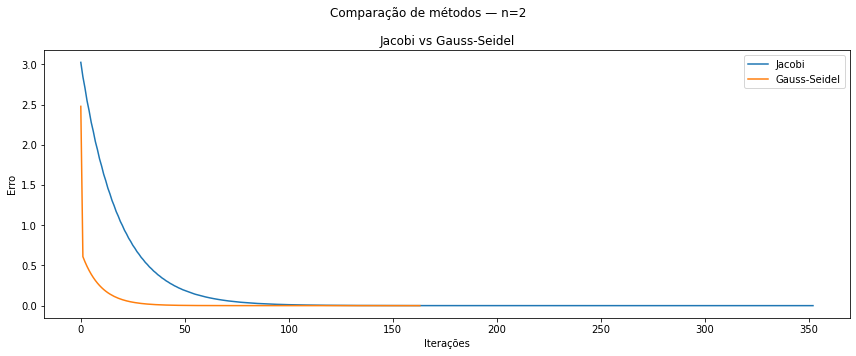

========== TAMANHO = 3 x 3 ==========
Jacobi:
Convergiu em 325 iterações
Resíduo: 1.13e-07
--------
Gauss-Seidel:
Convergiu em 179 iterações
Resíduo: 8.69e-08
--------


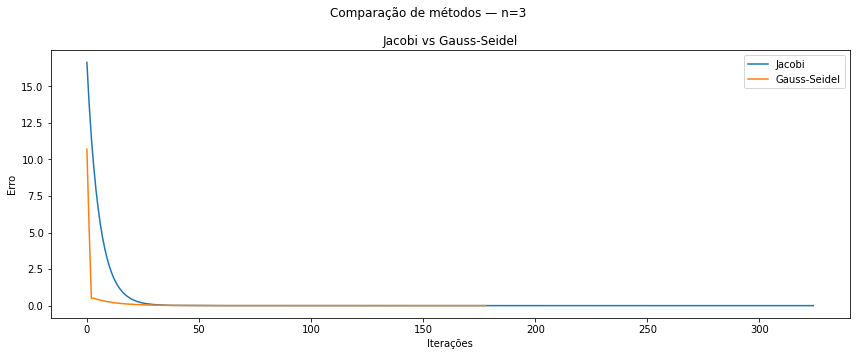

 ----- MATRIZES RANDÔMICAS ----- 
========== TAMANHO = 2 x 2 ==========
Jacobi:
Divergiu
Resíduo: 7.05e+04
--------
Gauss-Seidel:
Divergiu
Resíduo: 1.50e+09
--------


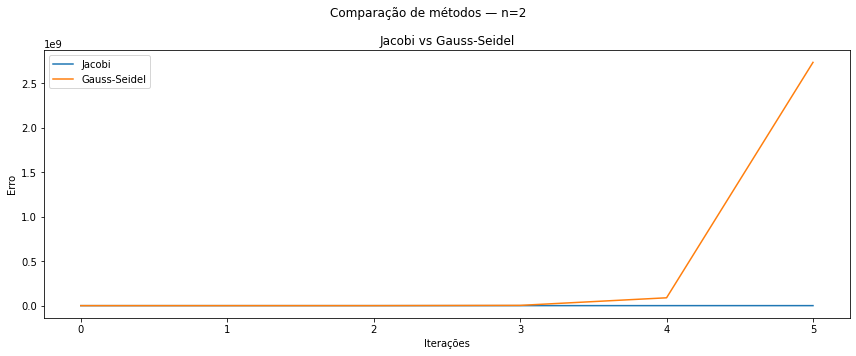

========== TAMANHO = 3 x 3 ==========
Jacobi:
Divergiu
Resíduo: 5.64e+02
--------
Gauss-Seidel:
Divergiu
Resíduo: 1.74e+01
--------


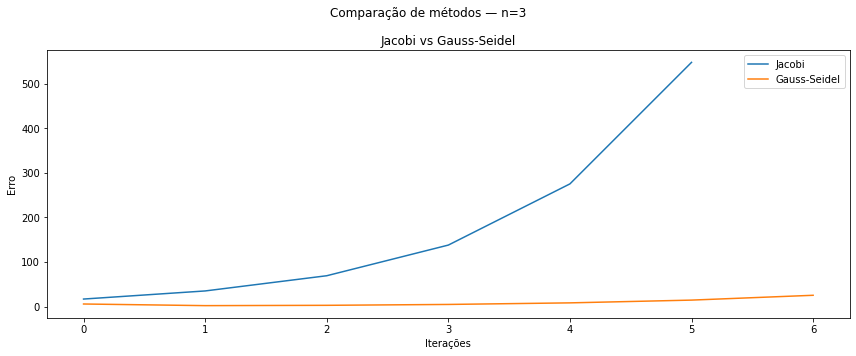

In [3]:
def gerar_sistema_diag_dominante(n):
    """
    gera um sistema linear Ax = b com matriz diagonalmente dominante.
 
    o vetor b é calculado como b = Ax, onde x é gerado aleatoriamente,
    garantindo que o sistema tem solução conhecida pra validação.
 
    parâmetros:
    -----------
        n : dimensão do sistema (matriz n x n)
 
    retorna:
    -------
        A : matriz dos coeficientes (n x n), diagonalmente dominante
        b : vetor do lado direito (n x 1)
    """
    
    x = np.random.uniform(-10, 10, size=n)
    A = np.random.uniform(-10, 10, size=(n, n))

    soma_linhas = np.sum(np.abs(A), axis=1) - np.abs(np.diag(A))
    
    #substituir a diagonal antiga 
    nova_diagonal = soma_linhas + np.random.uniform(0.1, 0.2, size=n)
    
    # np.fill_diagonal atuando em A
    np.fill_diagonal(A, nova_diagonal)
    
    b = A @ x
    
    return A, b


def gerar_sistema(n):
    """
    gera um sistema linear Ax = b onde A é uma matriz randômica.
 
    o vetor b é calculado como b = Ax, onde x é gerado aleatoriamente,
    garantindo que o sistema tem solução conhecida pra validação.
 
    parâmetros:
    -----------
        n : dimensão do sistema (matriz n x n)
 
    retorna:
    -------
        A : matriz dos coeficientes (n x n), diagonalmente dominante
        b : vetor do lado direito (n x 1)
    """
    
    # gera x
    x = np.random.uniform(1, 5, size=n)

    # monta matriz
    A = np.random.rand(n,n)

    b = A @ x

    return A, b


def testes(tamanhos, func) -> None:

    """
    executa e compara os quatro métodos iterativos para cada tamanho de sistema.
 
    pra cada n em tamanhos, gera um sistema linear usando func(n), roda os
    quatro métodos (Jacobi, Jacobi Matricial, Gauss-Seidel, GS Matricial),
    imprime o número de iterações e os raios espectrais, e plota dois gráficos
    comparando a evolução do erro por iteração.
 
    parâmetros:
    ----------
        tamanhos : lista de inteiros com os tamanhos de sistema a testar
        func : função geradora do sistema, com assinatura func(n) -> A, b
    """

    for n in tamanhos:
        A, b = func(n)
        A_np = np.array(A)
        b_np = np.array(b)

        print(f'========== TAMANHO = {n} x {n} ==========')
        # gerar funçoẽs
        print("Jacobi:")
        erros_j = jacobi(A_np, b_np, 1e-8)
        print("-"*8)
        print("Gauss-Seidel:")
        erros_gs = gauss_seidel(A_np, b_np, 1e-8)
        print("-"*8)
        
        fig, axs = plt.subplots(figsize=(12, 5))
        fig.suptitle(f"Comparação de métodos — n={n}")

        # Jacobi vs Gauss-Seidel
        axs.plot(erros_j, label="Jacobi")
        axs.plot(erros_gs, label="Gauss-Seidel")
        axs.set_title("Jacobi vs Gauss-Seidel")
        axs.set_xlabel("Iterações")
        axs.set_ylabel("Erro")
        axs.legend()


        plt.tight_layout()
        plt.show()



tamanhos = [2, 3]

testes(tamanhos, gerar_sistema_diag_dominante)

print(" ----- MATRIZES RANDÔMICAS ----- ")

testes(tamanhos, gerar_sistema)


<u>Comentários:</u>   Os elementos fora da diagonal de A foram gerados aleatoriamente em `[−10, 10]`, o que acaba garantindo a variabilidade sem muita instabilidade numérica. A diagonal principal foi definida como a soma dos valores absolutos dos demais elementos da linha somada com uma constante `C ∈ [0.1, 1]`, o que garante a dominância diagonal (propriedade suficiente para a convergência dos dois métodos).

Além disso, quando construimos o vetor `b` como o produto `b=Ax`, onde x é um vetor gerado aleatoriamente, podemos garantir que o sistema linear tem uma solução conhecida. Lembrando novamente que a função `gerar_sistema_diag_dominante` foi criada apenas para gerar os testes. 

Podemos ver que Gauss-Seidel converge mais rápido que Jacobi, as suas curvas de erro caem de forma mais brusca no início, enquanto Jacobi apresenta uma queda mais devagar. Isso ocorre porque Gauss-Seidel utiliza os valores mais recentes disponíveis a cada iteração, o que propaga as correções de forma mais rápida.

A comparação entre a velocidade das duas é feita por meio do erro ||xk - xsol||, o método converge quando esse erro se torna menor que uma tolerância já definida, que adotei como 1e-8.

<u>OBS:</u>  Decidi gerar os testes não apenas para matrizes com a propriedade de dominância diagonal, mas também para matrizes randômicas.


## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

========== TAMANHO = 4 x 4 ==========
Jacobi:
Divergiu
Resíduo: 9.30e+05
--------
Gauss-Seidel:
Divergiu
Resíduo: 1.35e+07
--------


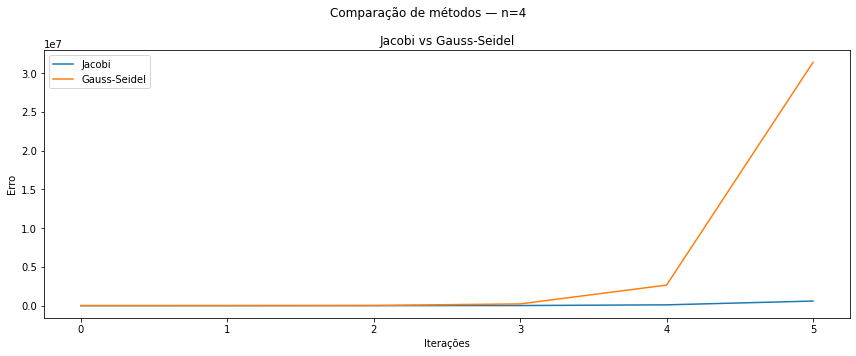

========== TAMANHO = 16 x 16 ==========
Jacobi:
Divergiu
Resíduo: 4.78e+10
--------
Gauss-Seidel:
Divergiu
Resíduo: 8.56e+21
--------


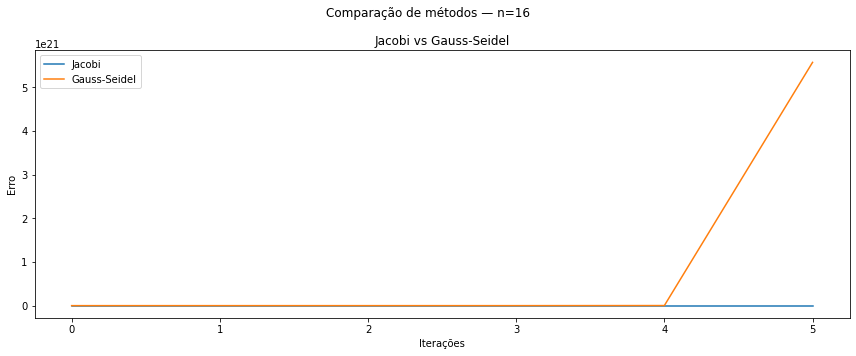

========== TAMANHO = 64 x 64 ==========
Jacobi:
Divergiu
Resíduo: 9.90e+15
--------
Gauss-Seidel:
Divergiu
Resíduo: 1.54e+63
--------


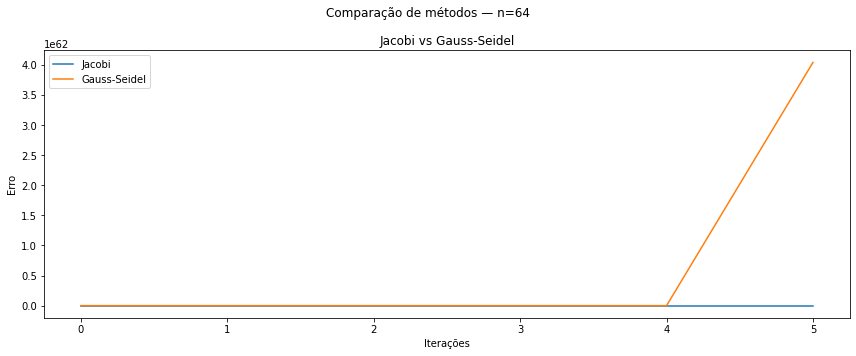

========== TAMANHO = 256 x 256 ==========
Jacobi:
Divergiu
Resíduo: 4.32e+20
--------
Gauss-Seidel:
Divergiu (overflow)
Resíduo: inf
--------


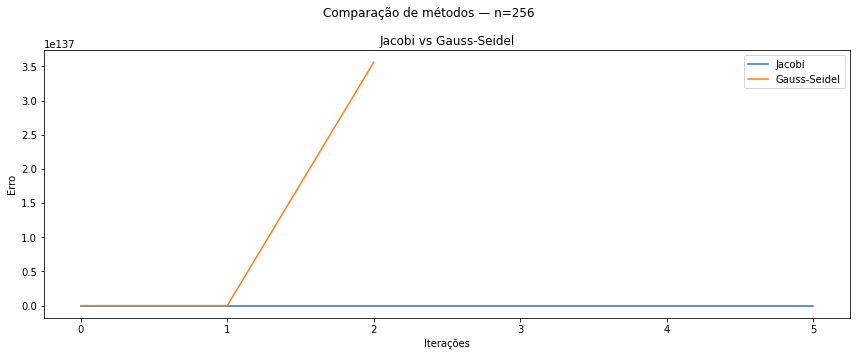

========== TAMANHO = 512 x 512 ==========
Jacobi:
Divergiu
Resíduo: 8.36e+22
--------
Gauss-Seidel:
Divergiu (overflow)
Resíduo: inf
--------


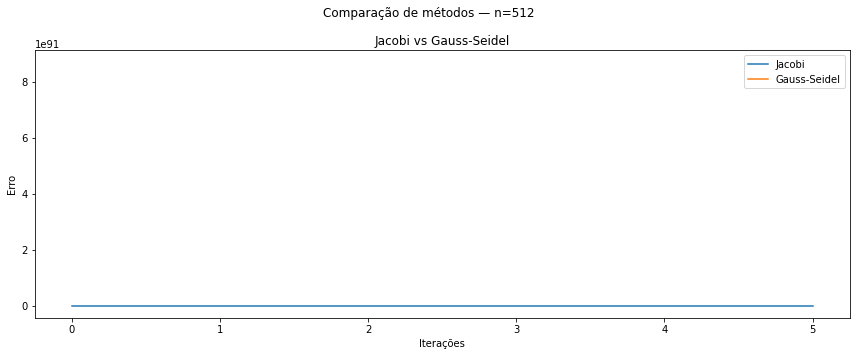

In [4]:
tamanhos = [4, 16, 64, 256, 512]

# utiliza a função teste para gerar testes com essas matrizes randômicas
testes(tamanhos, gerar_sistema)

<u>Comentários:</u>   Ao criar matriz do tipo `rand(m,m)`, não conseguimos garantir a dominância diagonal da matriz. Sem essa garantia, os métodos podem não convergir. Isso signfica que ao calcular os dois algoritmos, o erro não tende a zero ao longo das iterações, podendo crescer ou oscilar, o que indica divergência do método para esse tipo de matriz.


Existe a possibilidade de matrizes do tipo `rand(m,m)` que satisfaçam as condições de convergência, mas não é esperado que isso não ocorra. 


Quando a matriz não satisfaz as condições de convergência, as dependências entre variáveis de Gauss-Seidel “amplificam erros”, i.e., podem acelerar não apenas a convergência, mas também a propagação de erros(porque usa valores atualizados). Logo, em casos de divergência, é comum observar que o erro no Gauss-Seidel cresce mais rápido do que no método de Jacobi.

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?


===== m = 5 =====
m=5, k=3.3541, taxa=0.80
m=5, k=3.9131, taxa=0.95
k_jacobi ≈ 3.913118960624632, taxa = 0.95
m=5, k=3.3541, taxa=1.00
m=5, k=2.7951, taxa=0.75
m=5, k=3.0746, taxa=0.90
m=5, k=3.2143, taxa=0.95
k_gs ≈ 3.214347717655948, taxa = 0.95

===== m = 10 =====
m=10, k=4.7434, taxa=1.00
m=10, k=3.9528, taxa=0.65
m=10, k=4.3481, taxa=0.95
k_jacobi ≈ 4.348131782731522, taxa = 0.95
m=10, k=4.7434, taxa=1.00
m=10, k=3.9528, taxa=0.90
m=10, k=4.3481, taxa=0.95
k_gs ≈ 4.348131782731522, taxa = 0.95

===== m = 15 =====
m=15, k=5.8095, taxa=1.00
m=15, k=4.8412, taxa=0.65
m=15, k=5.3254, taxa=0.85
m=15, k=5.5674, taxa=1.00
m=15, k=5.4464, taxa=0.95
k_jacobi ≈ 5.446382830604181, taxa = 0.95
m=15, k=5.8095, taxa=0.95
k_gs ≈ 5.809475019311126, taxa = 0.95

===== m = 20 =====
m=20, k=6.7082, taxa=1.00
m=20, k=5.5902, taxa=0.90
m=20, k=6.1492, taxa=0.95
k_jacobi ≈ 6.149186938124422, taxa = 0.95
m=20, k=6.7082, taxa=1.00
m=20, k=5.5902, taxa=0.95
k_gs ≈ 5.5901699437494745, taxa = 0.95

===== m

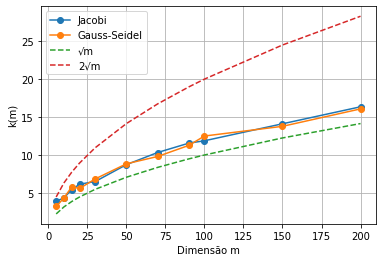

In [8]:
def convergiu_metodo(metodo, A, b, tol=1e-8, max_iter=300): #verifica se a matriz converge p determinado metodo
    erros = metodo(A, b, tol, max_iter, verbose=False)
    """
    verifica se um método converge pro sistema Ax = b.
 
    roda o método e verifica se o erro final ficou abaixo da tolerância.
 
    parâmetros:
    ----------
        metodo : função do método iterativo (jacobi, gauss_seidel, etc.)
        A : matriz dos coeficientes (n x n)
        b : vetor do lado direito (m x 1)
        tol : tolerância de convergência (padrão: 1e-8)
        max_iter : número máximo de iterações (padrão: 1000)
 
    retorna:
    -------
        True se convergiu, False caso contrário
    """
    
    if len(erros) == 0:
        return False
    
    # convergiu se último erro < tol
    return erros[-1] < tol


def gerar_A(m, k):
    """
    gera uma matriz do tipo randn(m,m) + k*I.

    parâmetros:
    -----------
        m : dimensão da matriz (m x m)
        k : valor somado à diagonal
 
    retorna:
    --------
        A : matriz (m x m) com entradas aleatórias e diagonal somada com k
    """

    A = np.random.randn(m, m)
    A += k * np.eye(m)
    return A


def taxa_convergencia(m, k, metodo, alvo=0.95, N=50): 
    """
    estima o valor de k(m) tal que um método iterativo converge em aproximadamente
    uma proporção alvo de sistemas lineares do tipo (randn(m,m) + k*I)x = b,
    utilizando busca binária para reduzir o custo computacional.

    a busca é feita no intervalo [sqrt(m), 2*sqrt(m)], assumindo que o valor
    de k cresce proporcionalmente a sqrt(m). em cada passo, calcula-se a taxa
    de convergência para um valor intermediário de k e ajusta-se o intervalo
    com base na comparação com a taxa alvo.

    parâmetros:
    -----------
        m : dimensão da matriz (m x m)
        metodo : função do método iterativo (jacobi, gauss_seidel, etc.)
        alvo : taxa de convergência desejada (padrão: 0.95)
        N : número de sistemas gerados para estimar a taxa (padrão: 20)
        tol : tolerância para parada da busca em k (padrão: 0.05)

    retorna:
    -------
        melhor_k : valor de k que melhor aproxima a taxa alvo
        taxa : taxa de convergência correspondente
    """
    count = 0
    
    for i in range(N):
        A = gerar_A(m, k)
        x_real = np.random.randn(m)
        b = A @ x_real
        
        if convergiu_metodo(metodo, A, b):
            count += 1

    
    return count / N

def encontrar_k(m, metodo, alvo_min=0.94, alvo_max=0.96, N=20, tol=0.05):
    k_low = np.sqrt(m)
    k_high = 2 * np.sqrt(m)
    
    melhor_k = None
    melhor_taxa = None
    melhor_erro = float('inf')
    
    while (k_high - k_low) > tol:
        k_mid = (k_low + k_high) / 2
        taxa = taxa_convergencia(m, k_mid, metodo, N=N)
        
        print(f"m={m}, k={k_mid:.4f}, taxa={taxa:.2f}")
        
        # condição ideal
        if alvo_min <= taxa <= alvo_max:
            return k_mid, taxa
        
        # guarda melhor aproximação
        erro = min(abs(taxa - alvo_min), abs(taxa - alvo_max))
        if erro < melhor_erro:
            melhor_erro = erro
            melhor_k = k_mid
            melhor_taxa = taxa
        
        # direção da busca
        if taxa < alvo_min:
            k_low = k_mid
        else:
            k_high = k_mid
    
    return melhor_k, melhor_taxa

def grafico_k(ms, jacobi, gauss_seidel):
    """
    executa um experimento comparando os métodos de Jacobi e Gauss-Seidel
    para diferentes dimensões m, estimando o valor de k associado a uma
    taxa de convergência desejada.

    para cada valor de m na lista ms:
        - calcula k para o método de Jacobi
        - calcula k para o método de Gauss-Seidel
        - armazena os resultados

    em seguida:
        - plota os valores obtidos k(m)
        - compara com as funções sqrt(m) e 2*sqrt(m)

    parâmetros:
    -----------
        ms : lista de dimensões do sistema (valores de m).
        jacobi : função que implementa Jacobi.
        gauss_seidel : Função que implementa o método de Gauss-Seidel.

    """
    ks_jacobi = []
    ks_gs = []

    for m in ms:

        print(f"\n===== m = {m} =====")
        k_j, taxa_j= encontrar_k(m, jacobi)
        print(f"k_jacobi ≈ {k_j}, taxa = {taxa_j}")
        ks_jacobi.append(k_j)

        
        k_gs, taxa_gs = encontrar_k(m, gauss_seidel)
        print(f"k_gs ≈ {k_gs}, taxa = {taxa_gs}")
        ks_gs.append(k_gs)


    ms = np.array(ms)
    ks_jacobi = np.array(ks_jacobi)
    ks_gs = np.array(ks_gs)

    # curvas de comparação
    sqrt_m = np.sqrt(ms)
    two_sqrt_m = 2 * np.sqrt(ms)

    plt.figure()

    # seus dados
    plt.plot(ms, ks_jacobi, 'o-', label='Jacobi')
    plt.plot(ms, ks_gs, 'o-', label='Gauss-Seidel')

    # cotas
    plt.plot(ms, sqrt_m, '--', label='√m')
    plt.plot(ms, two_sqrt_m, '--', label='2√m')

    plt.xlabel("Dimensão m")
    plt.ylabel("k(m)")
    plt.legend()
    plt.grid()

    plt.show()


ms = [5, 10, 15, 20, 30, 50, 70, 90, 100, 150, 200]
grafico_k(ms, jacobi, gauss_seidel)

<u>Comentários:</u>   Inicialmente eu tinha criado uma função encontrar_k que buscava k a partir de zero acrescido com um passo (o padrão era 0.2, mas quando a taxa de k para o certo m estava próximo de 0.85, eu mudava o passo pra 0.01). Percebi que era absurdamente custoso e decidi implementar o método de busca binária pra encontrar o k. A busca binária faz sentido aqui porque o comportamento da função que estamos analisando é monótono na prática: quando aumentamos k, a matriz fica mais “bem comportada” (mais dominante na diagonal), então a taxa de convergência tende a aumentar. Ou seja, existe um direcionamento melhor: se a taxa está baixa, precisamos aumentar k; se está alta demais, podemos diminuir. 

Temos que o intervalo [10, 200] já é suficiente para observar o comportamento dos métodos. 
É possível ver claramente como o valor de k cresce com m e também comparar bem o desempenho entre Jacobi e Gauss-Seidel. Não consegui enquadrar k(m) em uma função exata de m, mas após testar diferentes tipos de cotas, percebi que podemos limitar o k(m) por sqrt(m) e 2*sqrt(m). Além disso, o método de Gauss-Seidel atinge a taxa desejada com valores de k um pouco menores do que o método de Jacobi, o que indica maior eficiência, coerente com o que foi apresentado.

Esse comportamento pode ser interpretado pelo fato de que o termo 
k(m) aumenta a dominância diagonal da matriz, estabilizando o sistema e favorecendo a convergência dos métodos. À medida que m cresce, é necessário aumentar k(m) de forma aproximadamente proporcional a m.

A ideia da busca binária é simples: em vez de testar vários valores de k um por um (o que é muito lento), a gente começa com um intervalo onde sabemos que a solução está (por exemplo, entre sqrt(m) e 2*sqrt(m)) e sempre testa o ponto do meio. Dependendo da taxa obtida, descartamos metade do intervalo: se a taxa for baixa, olhamos só a metade maior; se for alta, ficamos com a metade menor. Repetindo isso, vamos fechando o cerco rápido até encontrar um valor de k próximo do desejado.

Isso reduz muito o custo computacional, porque em vez de testar muitos valores de forma linear, a gente encontra uma boa aproximação em poucas iterações.



## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

--- MATRIZ A ---
[[14.20935095 -1.9959309   3.85286309  8.24889551]
 [ 4.81280889  6.89598031 -1.78756545 -0.14885529]
 [-0.60480949  9.17639477 19.62922228  9.67269966]
 [-4.55302924 -2.11660498 -4.9295017  11.73611126]]
========== TAMANHO = 4 x 4 ==========
Jacobi:
Convergiu em 46 iterações
Resíduo: 6.66e-08
--------
Gauss-Seidel:
Convergiu em 68 iterações
Resíduo: 5.64e-08
--------
n=4: rho(Mj) = 0.6276
n=4: rho(Mgs) = 0.7304


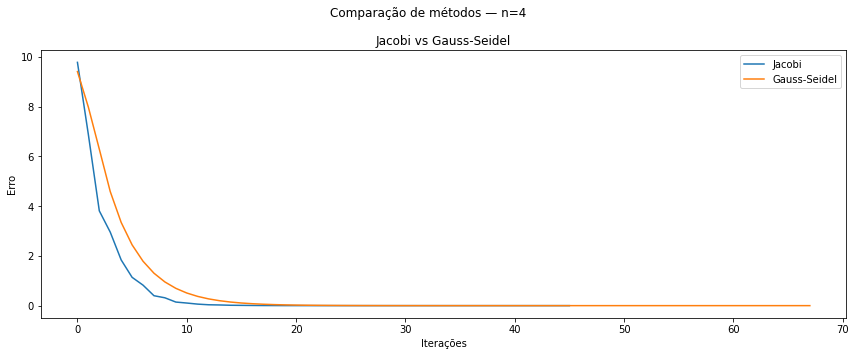

(46, 68)

In [6]:
def calcular_rho_mj(A):
    """
    calcula o raio espectral da matriz de iteração de Jacobi.
 
    a matriz de iteração é dada por:
        Mj = -D⁻¹ @ (L + U)
 
    parâmetros:
    -----------
        A : matriz dos coeficientes (n x n)
 
    retorna:
    -------
        rho : raio espectral de Mj (máximo do valor absoluto dos autovalores)
    """
        
    A = np.array(A)
    D = np.diag(np.diag(A))
    L = np.tril(A, k=-1)
    U = np.triu(A, k=1)
    Mj = -np.linalg.inv(D) @ (L + U)
    return max(abs(np.linalg.eigvals(Mj)))



def calcular_rho_mgs(A):
    """
    calcula o raio espectral da matriz de iteração de Gauss-Seidel.
 
    a matriz de iteração é dada por:
        Mgs = -(D + L)⁻¹ @ U
 
    parâmetros:
    -----------
        A : matriz dos coeficientes (n x n)
 
    retorna:
    --------
        rho : raio espectral de Mgs (máximo do valor absoluto dos autovalores)
    """

    A = np.array(A)
    D = np.diag(np.diag(A))
    L = np.tril(A, k=-1)
    U = np.triu(A, k=1)
    Mgs = -np.linalg.inv(D + L) @ U
    return max(abs(np.linalg.eigvals(Mgs)))

def filtro(n):
    """
    busca uma matriz diagonalmente dominante onde Jacobi converge mais
    rapidamente que Gauss-Seidel, comparando os raios espectrais das
    respectivas matrizes de iteração.
 
    gera matrizes aleatórias até encontrar uma que satisfaça:
        rho(Mj) < rho(Mgs) < 1
 
    parâmetros:
    -----------
        n : dimensão do sistema (matriz n x n)
 
    retorna:
    -------
        A : matriz (n x n) satisfazendo rho(Mj) < rho(Mgs) < 1
    """
    while True:
        A, b = gerar_sistema_diag_dominante(n)
        rho_mj = calcular_rho_mj(A)
        rho_mgs = calcular_rho_mgs(A)
        if rho_mj < rho_mgs < 1:
            return A


def teste_filtro(A, n, verbose=True) :
    """
    executa e compara os quatro métodos iterativos para a matriz A encontrada
    pelo filtro, onde Jacobi é esperado convergir mais rápido que Gauss-Seidel.
 
    gera um vetor x_real aleatório, computa b = A @ x_real e roda os quatro
    métodos. Imprime o número de iterações e os raios espectrais de Mj e Mgs.
    Se verbose=True, também plota os gráficos de convergência.
 
    parâmetros:
    -----------
        A : matriz dos coeficientes (n x n), obtida via filtro()
        n : dimensão do sistema
        verbose : se True, exibe prints e gráficos (padrão: True).
                  Use False pra montar tabelas.
 
    retorna:
    --------
        iteracoes_j : número de iterações do Jacobi escalar
        iteracoes_j_mat : número de iterações do Jacobi matricial
        iteracoes_gs : número de iterações do Gauss-Seidel escalar
        iteracoes_gs_mat : número de iterações do Gauss-Seidel matricial
    """
    
    x_real = np.random.uniform(-10, 10, size=4)
    b = A @ x_real
    A_np = np.array(A)
    b_np = np.array(b)


    print(f'========== TAMANHO = {n} x {n} ==========')
    # gerar funçoẽs
    print("Jacobi:")
    erros_j = jacobi(A_np, b_np, 1e-8)
    iteracoes_j = len(erros_j)
    print("-"*8)
    print("Gauss-Seidel:")
    erros_gs = gauss_seidel(A_np, b_np, 1e-8)
    iteracoes_gs = len(erros_gs)
    print("-"*8)
    print(f"n={n}: rho(Mj) = {calcular_rho_mj(A):.4f}")
    print(f"n={n}: rho(Mgs) = {calcular_rho_mgs(A):.4f}")

    if verbose:

        fig, axs = plt.subplots(figsize=(12, 5))
        fig.suptitle(f"Comparação de métodos — n={n}")
        # Jacobi vs Gauss-Seidel
        axs.plot(erros_j, label="Jacobi")
        axs.plot(erros_gs, label="Gauss-Seidel")
        axs.set_title("Jacobi vs Gauss-Seidel")
        axs.set_xlabel("Iterações")
        axs.set_ylabel("Erro")
        axs.legend()


        plt.tight_layout()
        plt.show()


    return iteracoes_j, iteracoes_gs


A = filtro(4)
print("--- MATRIZ A ---")
print(A)
teste_filtro(A, 4, verbose=True)

<u>Comentários:</u>   Para resolver essa questão, vamos usar o conceito de raio espectral. O raio espectral de uma matriz A é definido como o máximo do módulo dos autovalores de A. Em outras palavras, o raio espectral mede o quanto essa matriz consegue “esticar” ou “encolher” vetores. Se o raio espectral é menor que 1, isso significa que, a cada iteração, o erro fica menor, i.e., o método converge.  Além disso, o valor do raio espectral também diz quão rápido isso acontece. Se ele for bem pequeno, o erro diminui rápido; se for perto de 1, o erro até diminui, mas bem devagar. Ao impor que `ρ(MJ)<ρ(Mgs)`, garantimos que o método de Jacobi vai ter uma taxa de convergência mais rápida do que a taxa de convergência de Gauss-Seidel.

Lembrando que dizer que um método possui “melhor convergência” significa que ele atinge a solução com menor número de iterações, e não necessariamente que produz uma solução mais precisa. No experimento realizado, isso é representado no fato de que o método de Jacobi converge em menos iterações do que o método de Gauss-Seidel.

Note que não necessariamente a diferença de iterações entre os métodos é grande, o que faz com que a taxa de decaimento do erro seja muito parecida nos dois métodos. Por isso, temos que as curvas no gráfico apresentam comportamentos quase idênticos. 


## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à $A$? O que acontece se esta perturbação acontecer apenas fora da diagonal?

Matriz                         | It. Jacobi |   It. GS   |  ρ(Mj)   |  ρ(Mgs)  | Jacobi mais rápido? 
----------------------------------------------------------------------------------------------------
Original                       |     47     |     68     |  0.6276  |  0.7304  |         Sim         
----------------------------------------------------------------------------------------------------
Perturbada fora ε=0.01         |     45     |     68     |  0.6273  |  0.7305  |         Sim         
Perturbada fora ε=0.1          |     45     |     60     |  0.6251  |  0.7273  |         Sim         
Perturbada fora ε=1.0          |     47     |    100     |  0.6341  |  0.8042  |         Sim         
Perturbada fora ε=5.0          |     50     |     37     |  0.6487  |  0.5440  |         Não         

 ----- A NÃO PERTURBADO ----- 

========== TAMANHO = 4 x 4 ==========
Jacobi:
Convergiu em 47 iterações
Resíduo: 6.99e-08
--------
Gauss-Seidel:
Convergiu em 69 iterações
Resíduo: 6.24e

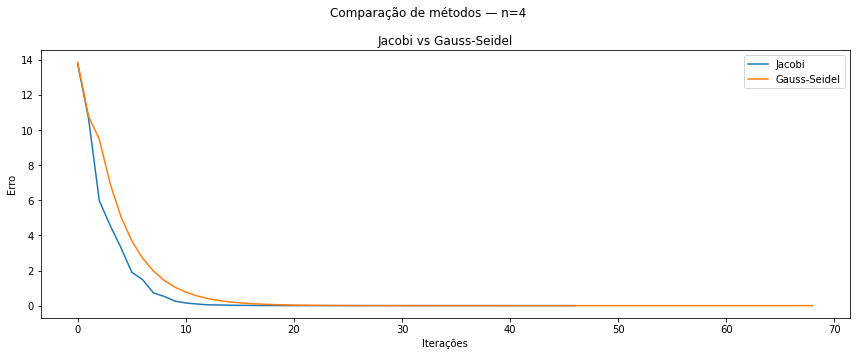


 ----- A COM MAIOR PERTURBAÇÃO ----- 

========== TAMANHO = 4 x 4 ==========
Jacobi:
Convergiu em 47 iterações
Resíduo: 9.40e-08
--------
Gauss-Seidel:
Convergiu em 34 iterações
Resíduo: 5.92e-08
--------
n=4: rho(Mj) = 0.6487
n=4: rho(Mgs) = 0.5440


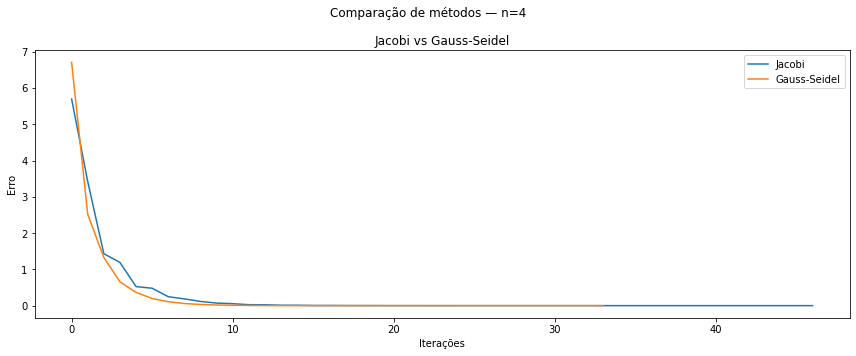

In [7]:
def calcular_metricas(A, n):
    """
    calcula o número de iterações necessárias para os métodos de Jacobi
    e Gauss-Seidel convergirem em um sistema linear Ax = b.

    o vetor b é gerado a partir de uma solução exata x_real aleatória,
    garantindo que o sistema tenha solução conhecida.

    parâmetros
    ----------
    A : Matriz do sistema linear.
    n : Dimensão do sistema.

    Retorno
    -------
        número de iterações até convergência para:
        - Jacobi
        - Gauss-Seidel
    """

    x_real = np.array([random.uniform(-10, 10) for _ in range(n)])
    b = A @ x_real
    A_np = np.array(A)
    b_np = np.array(b)
    erros_j  = jacobi(A_np, b_np, 1e-8, verbose=False)
    erros_gs = gauss_seidel(A_np, b_np, 1e-8, verbose=False)
    return len(erros_j), len(erros_gs)


escalas = [0.01, 0.1, 1.0, 5.0]

def gerar_tabela_metricas(A, escalas, n):
    """
    gera uma tabela comparando os métodos de Jacobi e Gauss-Seidel
    para a matriz original e versões perturbadas.

    para cada matriz:
        - calcula número de iterações até convergência
        - calcula raio espectral das matrizes de iteração
        - indica qual método foi mais rápido

    parâmetros
    ----------
    A : Matriz original do sistema.
    escalas : lista de intensidades de perturbação aplicadas fora da diagonal.
    n : dimensão da matriz.

    """
    it_j, it_gs = calcular_metricas(A, 4)
    rho_j = calcular_rho_mj(A)
    rho_gs = calcular_rho_mgs(A)
    mais_rapido = "Sim" if it_j < it_gs else "Não"

    print(f"{'Matriz':<30} | {'It. Jacobi':^10} | {'It. GS':^10} | {'ρ(Mj)':^8} | {'ρ(Mgs)':^8} | {'Jacobi mais rápido?':^20}")
    print("-" * 100)
    print(f"{'Original':<30} | {it_j:^10} | {it_gs:^10} | {rho_j:^8.4f} | {rho_gs:^8.4f} | {mais_rapido:^20}")
    print("-" * 100)

    for escala in escalas:
        epsilon_fora = [[0.0]*4 for _ in range(4)]
        for i in range(4):
            for j in range(4):
                if i != j:
                    epsilon_fora[i][j] = random.uniform(-escala, escala)
        A_fora = A + np.array(epsilon_fora)
        
        it_j_f, it_gs_f = calcular_metricas(A_fora, 4)
        rho_j_f = calcular_rho_mj(A_fora)
        rho_gs_f = calcular_rho_mgs(A_fora)
        mais_rapido = "Sim" if it_j_f < it_gs_f else "Não"
        label = f"Perturbada fora ε={escala}"
        print(f"{label:<30} | {it_j_f:^10} | {it_gs_f:^10} | {rho_j_f:^8.4f} | {rho_gs_f:^8.4f} | {mais_rapido:^20}")

    # plota só o original e o mais perturbado
    print("\n ----- A NÃO PERTURBADO ----- \n")
    teste_filtro(A, 4)
    print("\n ----- A COM MAIOR PERTURBAÇÃO ----- \n")
    teste_filtro(A + np.array(epsilon_fora), 4)


resultados = gerar_tabela_metricas(A, escalas, 4)

<u>Comentários:</u>  Podemos observar que perturbações pequenas aplicadas apenas aos elementos fora da diagonal não mudam muito o comportamento dos métodos. Em todos os casos analisados, o método de Jacobi se mantém mais rápido que o de Gauss-Seidel, o que é consistente com o fato de que ρ(Mj)<ρ(Mgs) em todas as instâncias.

Além disso, percebemos que os valores dos raios espectrais vão sofrer apenas variações médias, o que nos mostra que a estrutura principal da matriz (em especial a dominância diagonal) foi preservada mesmo depois das perturbações. Como consequência, o número de iterações também não apresenta mudanças muito drásticas, permanecendo na mesma ordem de grandeza.

Por outro lado, para perturbações maiores (como ε=1.0 e ε=5.0), podemos observar um comportamento menos previsível no número de iterações. Em particular, tem casos em que os dois métodos convergem mais rapidamente, o que nos sugere que a perturbação pode, ocasionalmente, reduzir o raio espectral das matrizes de iteração. É possível ver todos esses dados na tabela criada e nos gráficos criados de A / A com maior perturbação.


Resumindo, os resultados indicam que os métodos são relativamente robustos a pequenas perturbações fora da diagonal, e que a relação entre os raios espectrais continua sendo um bom indicador da velocidade de convergência, mesmo após modificações na matriz.